**IMPORT DAS BIBLIOTECAS**

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [4]:
DADOS = '/content/base.xlsx'
df_base = pd.read_excel(DADOS)

In [5]:
print(df_base.head())

   num_compra  usuario    nome  dados               Filial  \
0    24937847      295  Daniel     12  Loja Armando Mendes   
1    23600787      295  Daniel     12           Loja Manoa   
2    24298956      295  Daniel     12           Loja Manoa   
3    23802765      331    Alex     12           Loja Manoa   
4    22559356      331    Alex     12           Loja Manoa   

          data_compra valor_compra  Imposto Informado sobre imposto?  
0 2019-01-06 11:53:01       129.12   R$2.60                      Sim  
1 2019-06-01 17:27:11        95.96   R$1.94                      Sim  
2 2019-06-22 16:40:21       506.05  R$10.21                      Sim  
3 2019-06-11 20:10:43       586.20  R$11.82                      Sim  
4 2019-05-14 19:26:41        57.86   R$1.17                      Sim  


**TRATAMENTO DOS DADOS - LIMPEZA, RENOMEAÇÃO, EXCLUSÃO DE VALORES NAS COLUNAS**

In [6]:
df_base.columns = ['id_compra', 'id_vendedor', 'nome_vendedor', 'dados','filial', 'data_compra', 'valor_compra', 'valor_imposto', 'imposto_informado']

In [7]:
print(df_base.head())

   id_compra  id_vendedor nome_vendedor  dados               filial  \
0   24937847          295        Daniel     12  Loja Armando Mendes   
1   23600787          295        Daniel     12           Loja Manoa   
2   24298956          295        Daniel     12           Loja Manoa   
3   23802765          331          Alex     12           Loja Manoa   
4   22559356          331          Alex     12           Loja Manoa   

          data_compra valor_compra valor_imposto imposto_informado  
0 2019-01-06 11:53:01       129.12        R$2.60               Sim  
1 2019-06-01 17:27:11        95.96        R$1.94               Sim  
2 2019-06-22 16:40:21       506.05       R$10.21               Sim  
3 2019-06-11 20:10:43       586.20       R$11.82               Sim  
4 2019-05-14 19:26:41        57.86        R$1.17               Sim  


In [8]:
print(df_base['valor_imposto'])

0         R$2.60
1         R$1.94
2        R$10.21
3        R$11.82
4         R$1.17
          ...   
11995     R$4.89
11996     R$1.89
11997     R$5.27
11998     R$0.44
11999     R$0.17
Name: valor_imposto, Length: 12000, dtype: object


In [9]:
df_base['valor_compra'] = pd.to_numeric(df_base['valor_compra'], errors='coerce')
df_base['valor_imposto'] = (df_base['valor_imposto']
                             .astype(str)                  # Ensure it's string type
                             .str.replace('R$', '', regex=False)  # Remove 'R$' symbol
                             .str.replace(',', '.', regex=False)) # Replace comma with dot for decimals
df_base['valor_imposto'] = pd.to_numeric(df_base['valor_imposto'], errors='coerce')

In [10]:
print(df_base['valor_imposto'])

0         2.60
1         1.94
2        10.21
3        11.82
4         1.17
         ...  
11995     4.89
11996     1.89
11997     5.27
11998     0.44
11999     0.17
Name: valor_imposto, Length: 12000, dtype: float64


In [11]:
df_base['nome_vendedor'] = (df_base['nome_vendedor']
              .astype(str)                  # Garante que tudo é texto
              .str.strip()                  # Remove espaços nas pontas
              .str.replace(r'\s+', ' ', regex=True) # Remove espaços duplos
              .str.title())                 # Padroniza letras maiúsculas

In [12]:
print(df_base.dtypes)

id_compra                     int64
id_vendedor                   int64
nome_vendedor                object
dados                         int64
filial                       object
data_compra          datetime64[ns]
valor_compra                float64
valor_imposto               float64
imposto_informado            object
dtype: object


In [13]:
# Transforma a data-hora em somente data
df_base['data_compra'] = df_base['data_compra'].dt.date

In [14]:
# Exclusão da coluna dados que não é relevante pra análise
df_base = df_base.drop('dados', axis=1)
df_base = df_base.drop('id_compra', axis=1)

In [15]:
#Limpeza de linhas duplicadas
df_base = df_base.drop_duplicates()

In [16]:
#cria um outro arquivo onde os dados estão tratados
df_base.to_excel('base_tratado.xlsx', index=False)

**ANÁLISE DOS DADOS**

In [17]:
DADOS_TRATADOS = '/content/base_tratado.xlsx'
df_base_tratado = pd.read_excel(DADOS_TRATADOS)

In [18]:
# VALOR TOTAL VENDIDO
total_vendido = df_base_tratado['valor_compra'].sum()
print(f"Valor total vendido: R$ {total_vendido:.2f}")

Valor total vendido: R$ 1352835.35


In [19]:
# Calcula a média de vendas por mês
media_vendas_por_mes = df_base_tratado.groupby(df_base_tratado['data_compra'].dt.to_period('M'))['valor_compra'].mean()

print(f"Valor total vendido: R$ {total_vendido:.2f}\n")
print("Média de Vendas por Mês:")
print(media_vendas_por_mes)

Valor total vendido: R$ 1352835.35

Média de Vendas por Mês:
data_compra
2019-01    113.842183
2019-05    113.146948
2019-06    112.164821
Freq: M, Name: valor_compra, dtype: float64


/tmp/ipykernel_2330/518827657.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y='filial', x='valor_compra', data=vendas_por_filial, palette='viridis')


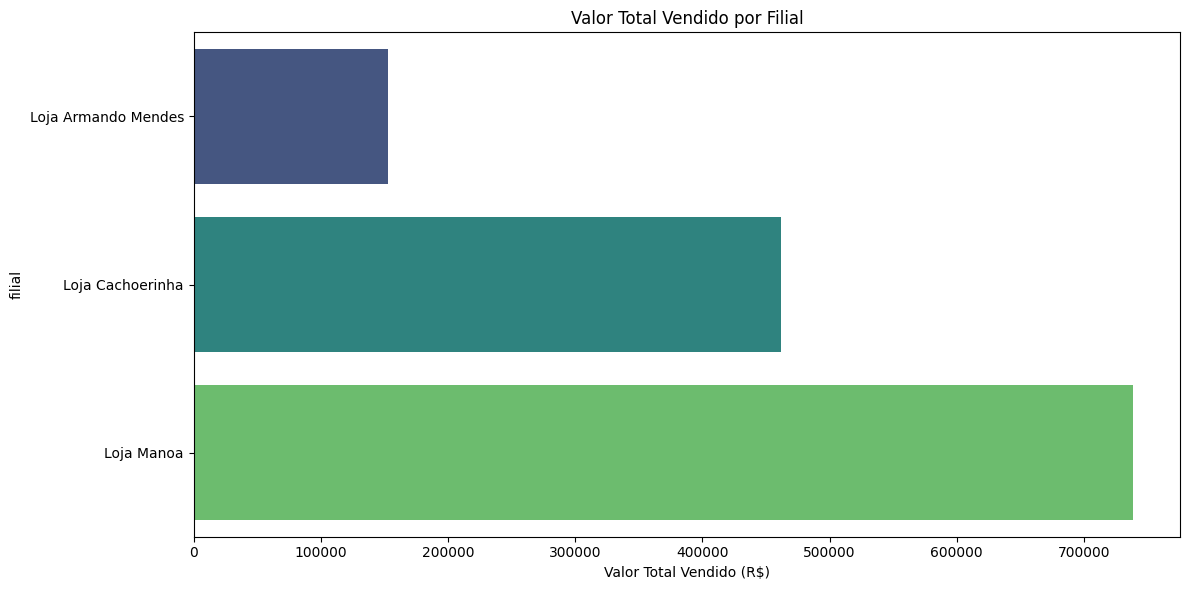

In [20]:
vendas_por_filial = df_base_tratado.groupby('filial')['valor_compra'].sum().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(y='filial', x='valor_compra', data=vendas_por_filial, palette='viridis')
plt.title('Valor Total Vendido por Filial')
plt.xlabel('Valor Total Vendido (R$)')
plt.tight_layout()
plt.show()

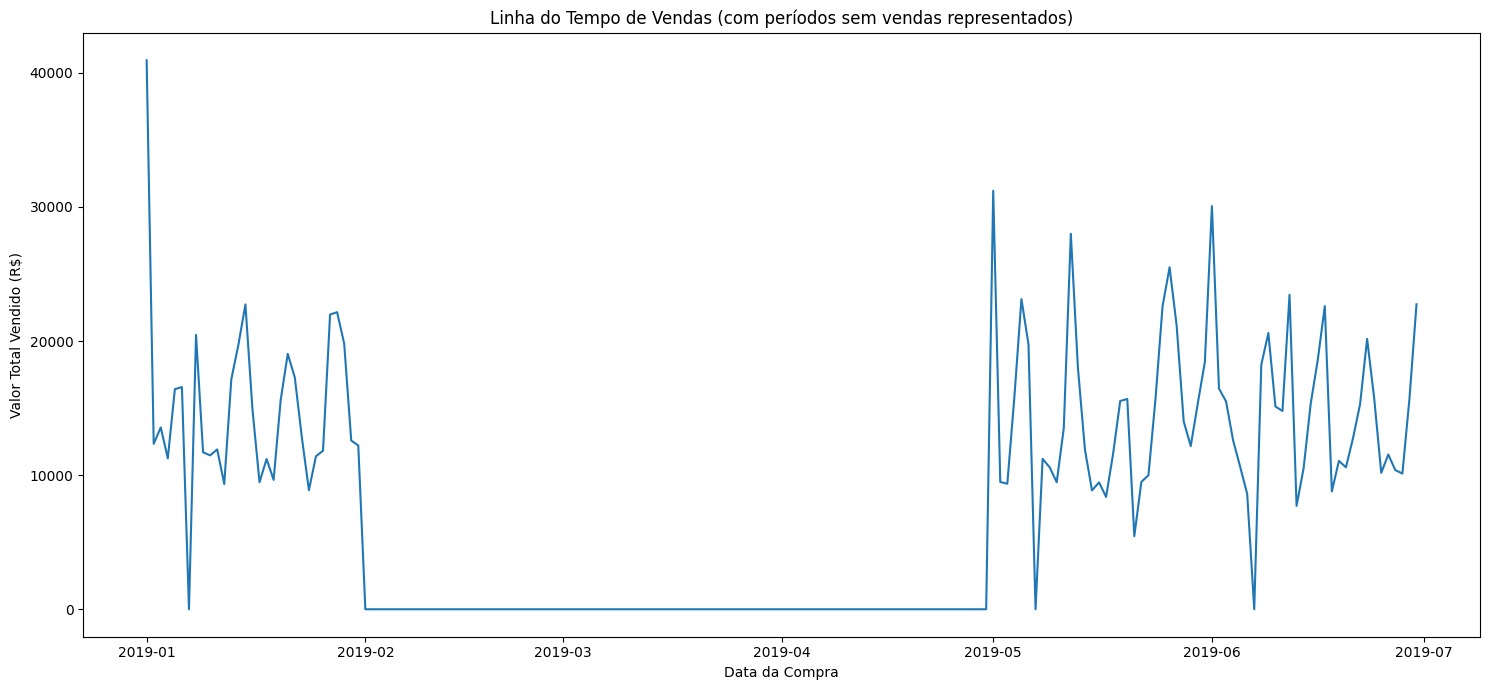

In [21]:
# Garante que a coluna 'data_compra' é do tipo datetime para manipulações de tempo
df_base_tratado['data_compra'] = pd.to_datetime(df_base_tratado['data_compra'])

# Agrupa as vendas por dia
vendas_por_data = df_base_tratado.groupby('data_compra')['valor_compra'].sum()

# Cria um intervalo completo de datas do menor ao maior dia de venda
min_date = vendas_por_data.index.min()
max_date = vendas_por_data.index.max()
full_date_range = pd.date_range(start=min_date, end=max_date, freq='D')

# Reindexa os dados de vendas com o intervalo completo, preenchendo as datas sem vendas com 0
vendas_com_zeros = vendas_por_data.reindex(full_date_range, fill_value=0).reset_index()
vendas_com_zeros.columns = ['data_compra', 'valor_compra'] # Renomeia colunas para o plot

plt.figure(figsize=(15, 7))
sns.lineplot(x='data_compra', y='valor_compra', data=vendas_com_zeros)
plt.title('Linha do Tempo de Vendas (com períodos sem vendas representados)')
plt.xlabel('Data da Compra')
plt.ylabel('Valor Total Vendido (R$)')
plt.tight_layout()
plt.show()

/tmp/ipykernel_2330/4196904293.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y='nome_vendedor', x='valor_compra', data=vendas_por_vendedor_top10, palette='coolwarm')


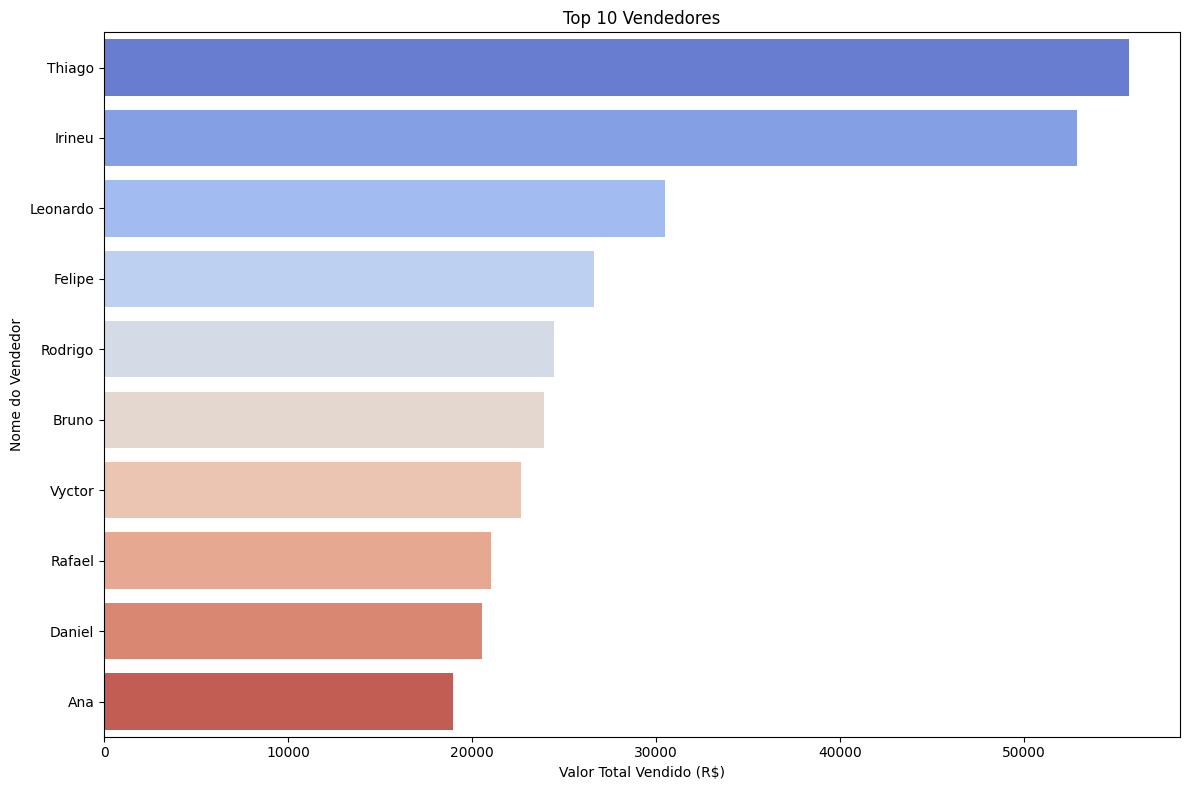

In [22]:
vendas_por_vendedor = df_base_tratado.groupby('nome_vendedor')['valor_compra'].sum().reset_index()
vendas_por_vendedor = vendas_por_vendedor.sort_values(by='valor_compra', ascending=False)

vendas_por_vendedor_top10 = vendas_por_vendedor.head(10)

plt.figure(figsize=(12, 8))
sns.barplot(y='nome_vendedor', x='valor_compra', data=vendas_por_vendedor_top10, palette='coolwarm')
plt.title('Top 10 Vendedores')
plt.xlabel('Valor Total Vendido (R$)')
plt.ylabel('Nome do Vendedor')
plt.tight_layout()
plt.show()

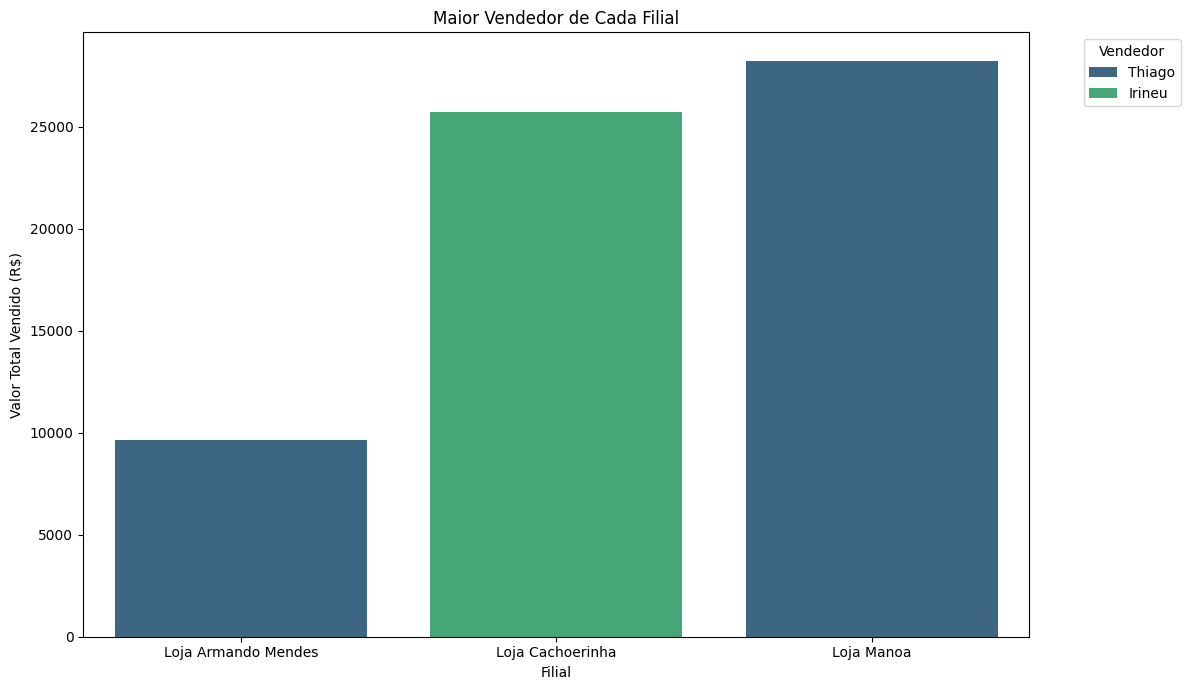

In [23]:
vendas_por_filial_vendedor = df_base_tratado.groupby(['filial', 'nome_vendedor'])['valor_compra'].sum().reset_index()

maior_vendedor_por_filial = vendas_por_filial_vendedor.loc[vendas_por_filial_vendedor.groupby('filial')['valor_compra'].idxmax()]

plt.figure(figsize=(12, 7))
sns.barplot(x='filial', y='valor_compra', data=maior_vendedor_por_filial, hue='nome_vendedor', palette='viridis', dodge=False)
plt.title('Maior Vendedor de Cada Filial')
plt.xlabel('Filial')
plt.ylabel('Valor Total Vendido (R$)')
plt.legend(title='Vendedor', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

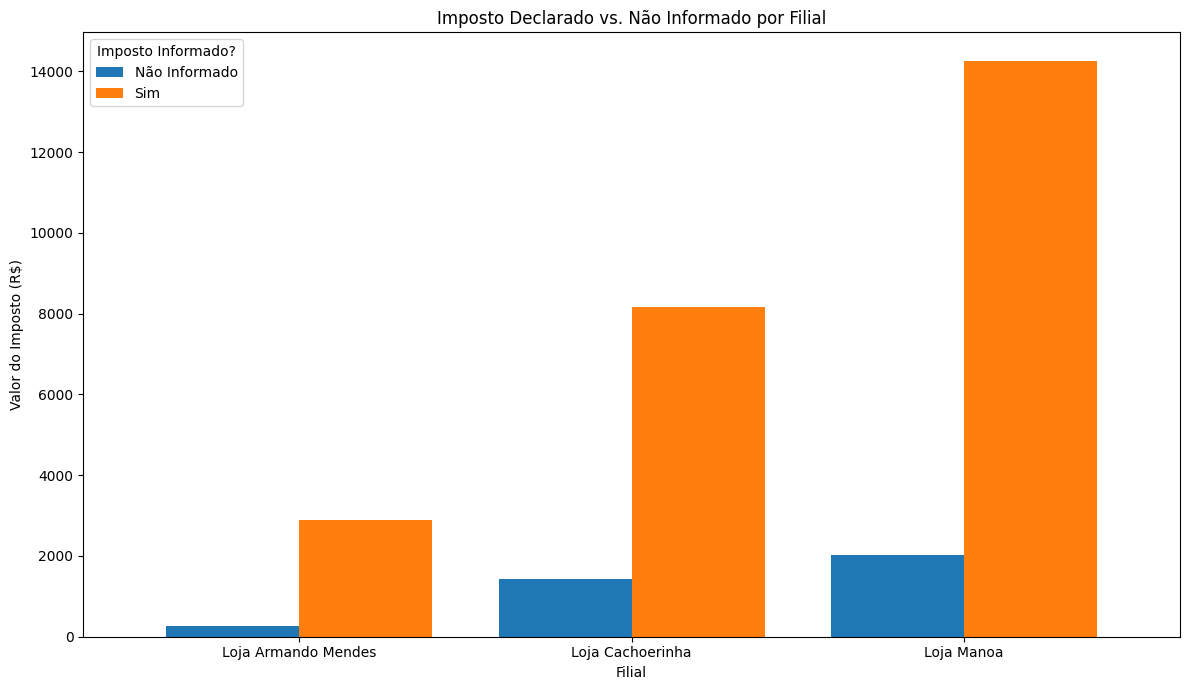

In [24]:
imposto_declarado_filial = df_base_tratado.groupby(['filial', 'imposto_informado'])['valor_imposto'].sum().unstack(fill_value=0)

imposto_declarado_filial.columns = ['Não Informado', 'Sim']

imposto_declarado_filial.plot(kind='bar', figsize=(12, 7), width=0.8)
plt.title('Imposto Declarado vs. Não Informado por Filial')
plt.xlabel('Filial')
plt.ylabel('Valor do Imposto (R$)')
plt.xticks(rotation=360, ha='center')
plt.legend(title='Imposto Informado?')
plt.tight_layout()
plt.show()

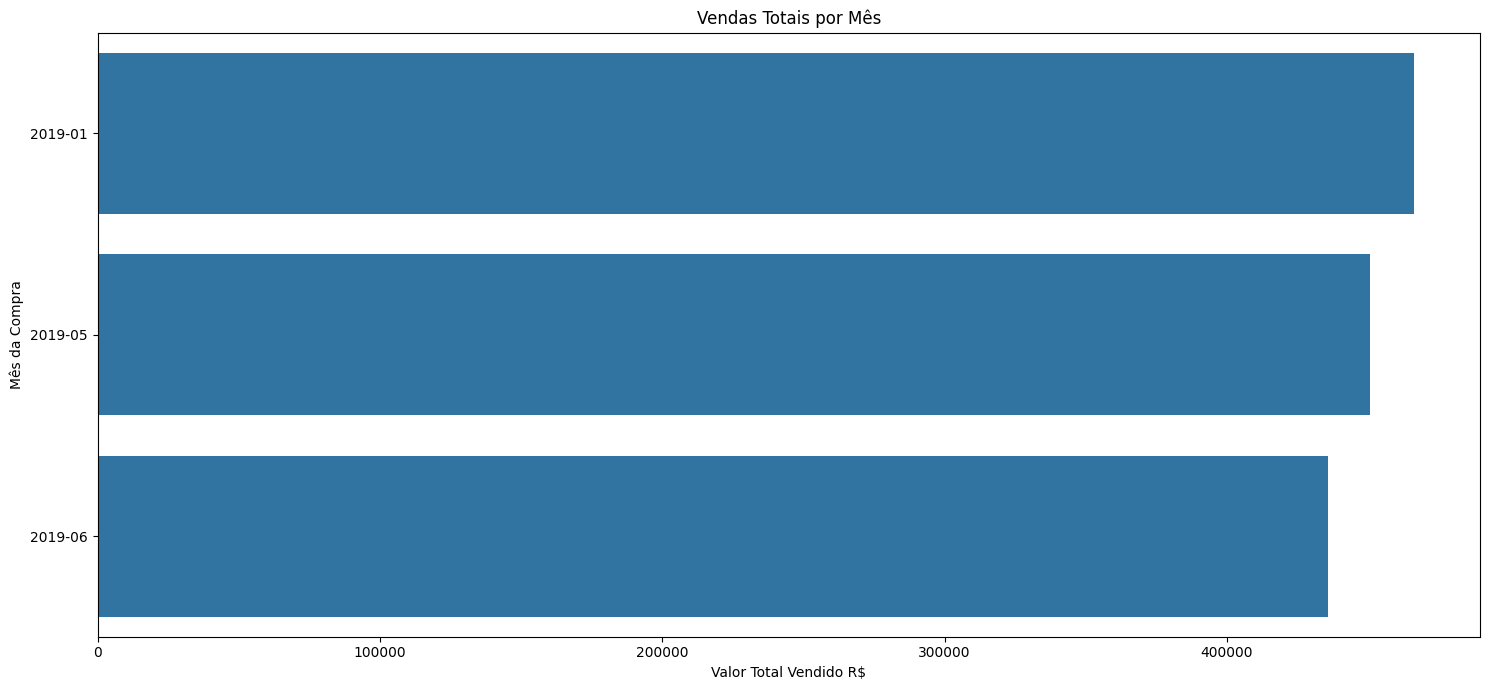

In [25]:
vendas_total_mes = df_base_tratado.groupby(df_base_tratado['data_compra'].dt.to_period('M'))['valor_compra'].sum().reset_index()
# Converte o Período do mês para string para melhor exibição no eixo x
vendas_total_mes['data_compra'] = vendas_total_mes['data_compra'].astype(str)

plt.figure(figsize=(15, 7))
sns.barplot(x='valor_compra', y='data_compra', data=vendas_total_mes)
plt.title('Vendas Totais por Mês')
plt.xlabel('Valor Total Vendido R$')
plt.ylabel('Mês da Compra')
plt.tight_layout()
plt.show()

**INSIGHTS**

* É possível notar com os gráficos, principalmente com o de vendas totais por mês, que houve um período de fevereiro até o final de abril em que não se foi feita nenhuma venda.

* Além disso, é possivel notar também que a Filial Manoa possui os maiores indicadores na maioria dos gráficos gerados (imposto declarado, total de vendas) além de possuir o vendedor de destaque dentre as filiais.